# MARTA GNN – Delay Risk Prediction Demo

1. Load demo dataset
2. Inspect data & graph
3. Train GCN and MLP baseline
4. Evaluate and compare

In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [2]:
import sys, os, logging, importlib, random
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), "src"))
sys.path.insert(0, os.path.join(os.getcwd(), "..", "src"))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
%matplotlib inline

from marta_gnn.training.trainer import Trainer, build_model, model_forward
from marta_gnn.training.evaluation import evaluate
import marta_gnn.visualization.plots as _plots_mod
importlib.reload(_plots_mod)
from marta_gnn.visualization.plots import (
    plot_training_curves, plot_confusion_matrix,
    plot_roc_curve, plot_graph_layout, plot_delay_distribution,
    plot_model_comparison,
    )
from sklearn.metrics import RocCurveDisplay

print(f"CUDA: {torch.cuda.is_available()}")

CUDA: False


## 1. Hyperparameters

Adjust the values below before training. Re-run this cell and the training cells to experiment.

In [3]:
# ── Model architecture ──
HIDDEN_DIM   = 64      # hidden layer size
NUM_LAYERS   = 2       # GCN conv layers
DROPOUT      = 0.5     # dropout rate

# ── Optimiser ──
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-3

# ── Training schedule ──
EPOCHS   = 200
PATIENCE = 50

# ── Data splits ──
TRAIN_RATIO = 0.6
VAL_RATIO   = 0.2
TEST_RATIO  = 0.2
SEED        = 10

# ── Feature / label settings ──
DELAY_THRESHOLD = 300

# ─────────────────────────────────────────────
cfg = {
    "data":     {"use_mock": True, "mock_num_stops": 800, "mock_num_routes": 30,
                 "mock_num_trips": 200, "processed_dir": "data/processed"},
    "features": {"time_bins": 24, "delay_threshold_seconds": DELAY_THRESHOLD,
                 "historical_window_days": 7},
    "model":    {"type": "gcn", "hidden_dim": HIDDEN_DIM, "num_layers": NUM_LAYERS,
                 "dropout": DROPOUT, "learning_rate": LEARNING_RATE,
                 "weight_decay": WEIGHT_DECAY, "epochs": EPOCHS,
                 "patience": PATIENCE, "batch_size": 32},
    "training": {"train_ratio": TRAIN_RATIO, "val_ratio": VAL_RATIO,
                 "test_ratio": TEST_RATIO, "seed": SEED},
    "logging":  {"level": "INFO", "file": ""},
}

logging.basicConfig(level=logging.INFO, format="%(message)s", force=True)
logging.getLogger("marta_gnn.training.trainer").setLevel(logging.INFO)


def clone_cfg(config):
    return {k: (dict(v) if isinstance(v, dict) else v) for k, v in config.items()}


def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def train_and_evaluate(model_type, data, base_cfg=None):
    """Train a model and return (model, history, results). Reduces repetition."""
    c = clone_cfg(base_cfg or cfg)
    c["model"]["type"] = model_type
    set_global_seed(c["training"]["seed"])
    model = build_model(c, in_dim=data.x.shape[1])
    history = Trainer(c).train(model, data)
    results = evaluate(model, data)
    return model, history, results

## 2. Load Demo Dataset

In [4]:
from marta_gnn.data.dataset_builder import DatasetBuilder
from marta_gnn.data.mock_data import generate_mock_data

set_global_seed(cfg["training"]["seed"])

mock = generate_mock_data(cfg)
tables = {
    "stops": mock["stops"],
    "routes": mock["routes"],
    "trips": mock["trips"],
    "stop_times": mock["stop_times"],
}
data = DatasetBuilder(cfg).build(tables=tables, realtime=mock.get("realtime"))

expected_stops = cfg["data"]["mock_num_stops"]
generated_stops = len(mock["stops"])
if generated_stops != expected_stops:
    raise ValueError(f"Expected {expected_stops} mock stops, got {generated_stops}.")
if int(data.num_nodes) != generated_stops:
    raise ValueError(
        f"Graph node count ({data.num_nodes}) does not match generated stops ({generated_stops})."
    )

labels, counts = data.y.unique(return_counts=True)
label_counts = dict(zip(labels.tolist(), counts.tolist()))

print(f"Configured stops:   {expected_stops}")
print(f"Generated stops:    {generated_stops}")
print(f"Graph nodes:        {data.num_nodes}")
print(f"Edges:              {data.edge_index.shape[1]}")
print(f"Features:           {data.x.shape[1]}")
print(f"Labels:             {label_counts}")
print(f"Train/Val/Test:     {int(data.train_mask.sum())}/{int(data.val_mask.sum())}/{int(data.test_mask.sum())}")

Generated mock data: 800 stops, 30 routes, 200 trips, 2818 stop_times, 2818 RT updates
Graph has 800 nodes (stops)
Graph has 5236 edges
Node feature dim after enrichment: 12
Labels: 96 at-risk (12.0%), 704 on-time
Splits: train=479, val=159, test=162


Configured stops:   800
Generated stops:    800
Graph nodes:        800
Edges:              5236
Features:           12
Labels:             {0: 704, 1: 96}
Train/Val/Test:     479/159/162


## 3. Inspect Data

In [5]:
for name, df in mock.items():
    print(f"{name:15s}: {len(df):6d} rows")

mock["stops"].head()

stops          :    800 rows
routes         :     30 rows
trips          :    200 rows
stop_times     :   2818 rows
realtime       :   2818 rows


,stop_id,stop_name,stop_lat,stop_lon,wheelchair_boarding
0,STOP_0000,Mock Stop 0,33.683800,-84.492423,0
1,STOP_0001,Mock Stop 1,33.706499,-84.296658,2
2,STOP_0002,Mock Stop 2,33.703092,-84.521744,1
3,STOP_0003,Mock Stop 3,33.766019,-84.336819,2
4,STOP_0004,Mock Stop 4,33.735085,-84.440269,1


In [6]:
mock["realtime"].head()

,trip_id,stop_id,stop_sequence,arrival_delay,departure_delay,timestamp
0,TRIP_0000,STOP_0027,0,120,113,1700054334
1,TRIP_0000,STOP_0038,1,73,99,1700018598
2,TRIP_0000,STOP_0136,2,1559,1578,1700069707
3,TRIP_0000,STOP_0179,3,645,641,1700034869
4,TRIP_0000,STOP_0190,4,32,35,1700048998


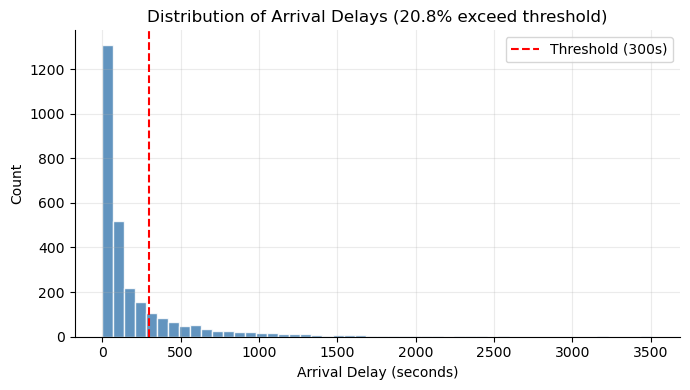

In [7]:
from marta_gnn.visualization.plots import plot_delay_distribution

delays = mock["realtime"]["arrival_delay"].values.astype(float)
fig = plot_delay_distribution(delays, threshold=300)
plt.show()

### Stop Map (ground truth labels)

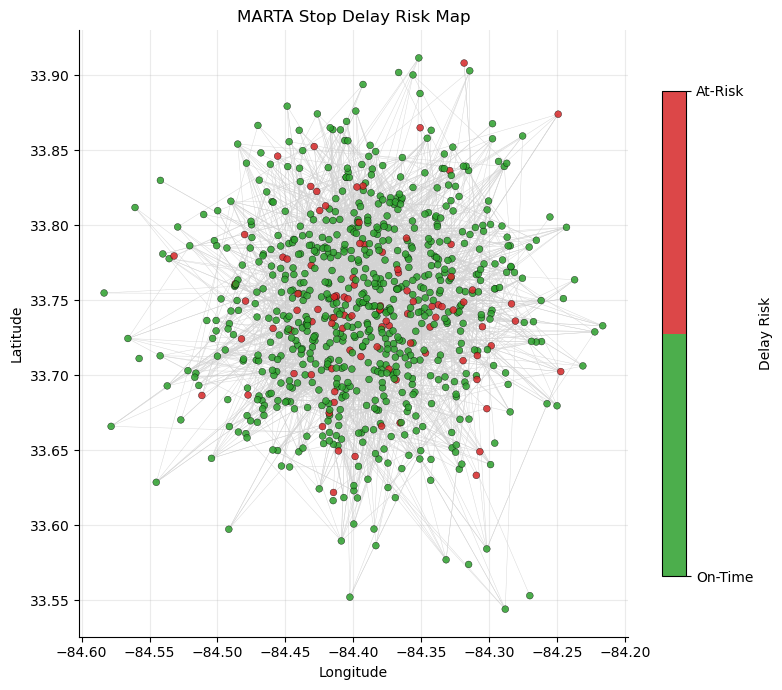

In [8]:
from marta_gnn.visualization.plots import plot_graph_layout

fig = plot_graph_layout(data)
plt.show()

## 4. Train GCN

In [9]:
gcn_model, gcn_history, gcn_results = train_and_evaluate("gcn", data)
print(gcn_model)

Epoch   1 | loss=0.8501 val_loss=1.2729 | acc=0.852 val_acc=0.836 | MAE=0.2444 MSE=0.1332 RMSE=0.3649
Epoch   2 | loss=0.8687 val_loss=0.8988 | acc=0.839 val_acc=0.824 | MAE=0.3379 MSE=0.1530 RMSE=0.3912
Epoch   3 | loss=0.8232 val_loss=0.7796 | acc=0.825 val_acc=0.824 | MAE=0.4077 MSE=0.1854 RMSE=0.4306
Epoch   4 | loss=0.8235 val_loss=0.7327 | acc=0.770 val_acc=0.767 | MAE=0.4582 MSE=0.2192 RMSE=0.4682
Epoch   5 | loss=0.8386 val_loss=0.7128 | acc=0.580 val_acc=0.616 | MAE=0.4966 MSE=0.2514 RMSE=0.5014
Epoch   6 | loss=0.8476 val_loss=0.7069 | acc=0.313 val_acc=0.270 | MAE=0.5245 MSE=0.2785 RMSE=0.5278
Epoch   7 | loss=0.8111 val_loss=0.7073 | acc=0.150 val_acc=0.138 | MAE=0.5456 MSE=0.3013 RMSE=0.5489
Epoch   8 | loss=0.8091 val_loss=0.7103 | acc=0.117 val_acc=0.119 | MAE=0.5618 MSE=0.3202 RMSE=0.5658
Epoch   9 | loss=0.7508 val_loss=0.7132 | acc=0.119 val_acc=0.119 | MAE=0.5729 MSE=0.3339 RMSE=0.5778
Epoch  10 | loss=0.8153 val_loss=0.7154 | acc=0.121 val_acc=0.119 | MAE=0.5810 MSE

GCNModel(
  (convs): ModuleList(
    (0): GCNConv(12, 64)
    (1): GCNConv(64, 2)
  )
  (bns): ModuleList(
    (0): BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)


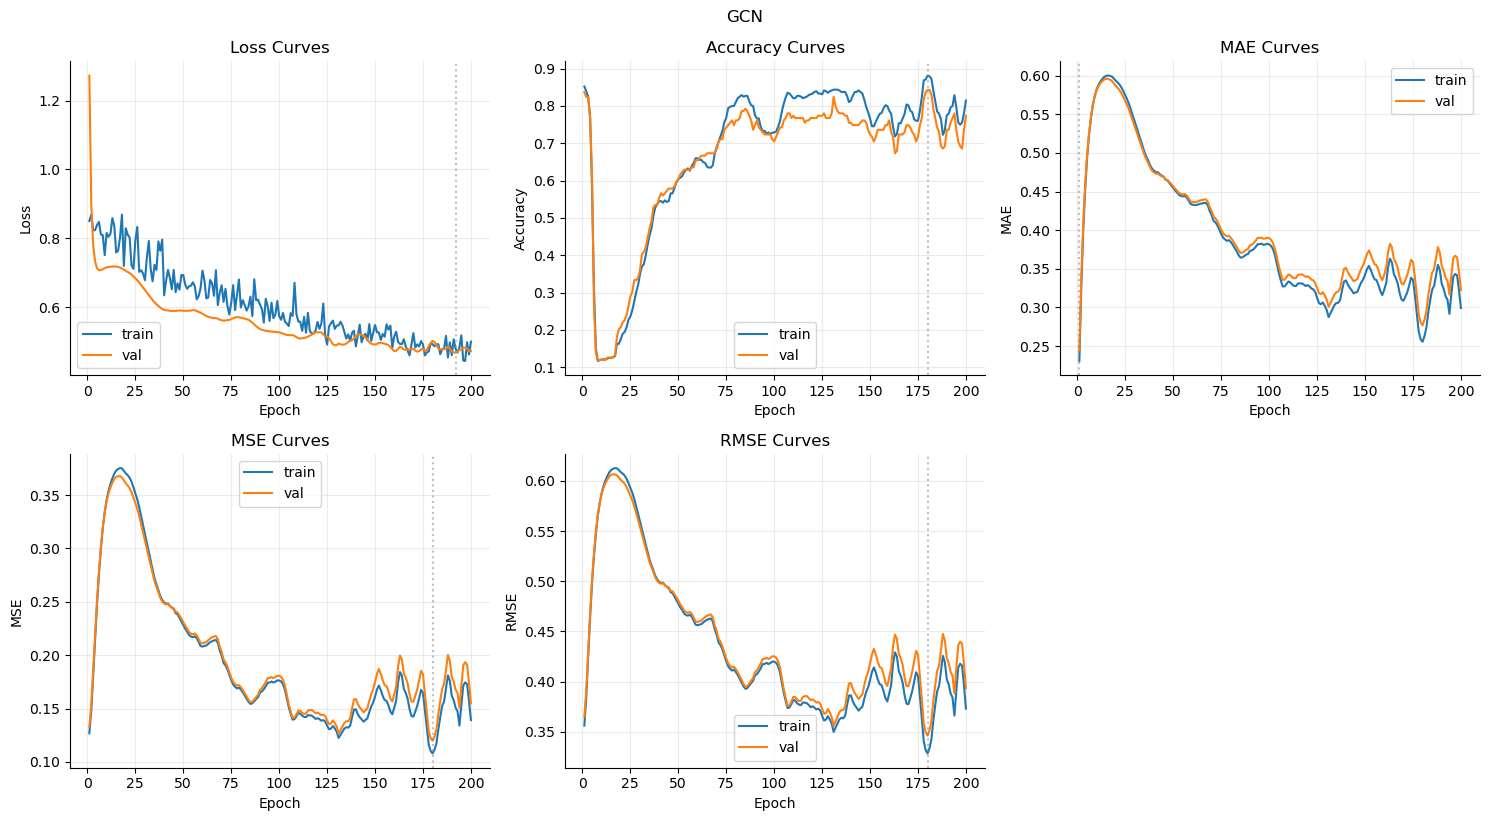

In [10]:
fig = plot_training_curves(gcn_history)
plt.suptitle("GCN", y=1.02); plt.show()

## 5. Train MLP Baseline

In [11]:
mlp_model, mlp_history, mlp_results = train_and_evaluate("mlp", data)

Epoch   1 | loss=0.7781 val_loss=0.7470 | acc=0.225 val_acc=0.252 | MAE=0.6164 MSE=0.4127 RMSE=0.6424
Epoch   2 | loss=0.6559 val_loss=0.6791 | acc=0.236 val_acc=0.258 | MAE=0.5725 MSE=0.3480 RMSE=0.5899
Epoch   3 | loss=0.7320 val_loss=0.6531 | acc=0.244 val_acc=0.296 | MAE=0.5495 MSE=0.3164 RMSE=0.5625
Epoch   4 | loss=0.7112 val_loss=0.6385 | acc=0.253 val_acc=0.308 | MAE=0.5361 MSE=0.2992 RMSE=0.5470
Epoch   5 | loss=0.6756 val_loss=0.6277 | acc=0.276 val_acc=0.327 | MAE=0.5256 MSE=0.2862 RMSE=0.5350
Epoch   6 | loss=0.7265 val_loss=0.6201 | acc=0.296 val_acc=0.352 | MAE=0.5184 MSE=0.2776 RMSE=0.5269
Epoch   7 | loss=0.6701 val_loss=0.6144 | acc=0.315 val_acc=0.384 | MAE=0.5124 MSE=0.2704 RMSE=0.5200
Epoch   8 | loss=0.6808 val_loss=0.6100 | acc=0.359 val_acc=0.415 | MAE=0.5086 MSE=0.2661 RMSE=0.5159
Epoch   9 | loss=0.6794 val_loss=0.6059 | acc=0.384 val_acc=0.459 | MAE=0.5058 MSE=0.2632 RMSE=0.5130
Epoch  10 | loss=0.6600 val_loss=0.6009 | acc=0.415 val_acc=0.472 | MAE=0.5037 MSE

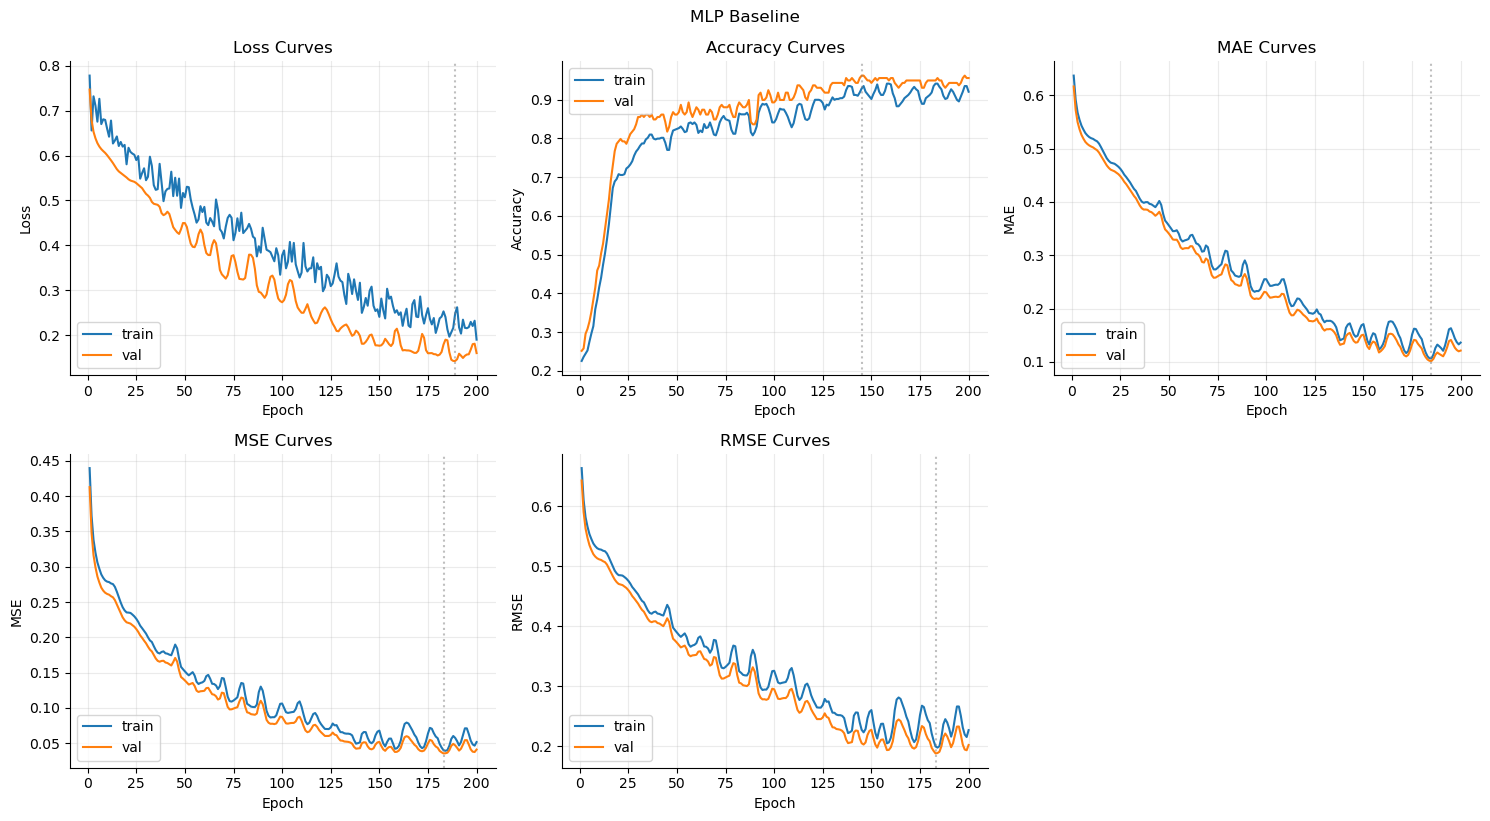

In [12]:
fig = plot_training_curves(mlp_history)
plt.suptitle("MLP Baseline", y=1.02); plt.show()

## 6. Evaluate & Compare

In [13]:
gcn_results = evaluate(gcn_model, data)
mlp_results = evaluate(mlp_model, data)

for name, res in [("GCN", gcn_results), ("MLP", mlp_results)]:
    print(f"{'='*40}\n{name}\n{'='*40}")
    print(res["classification_report"])
    print(f"  MAE:  {res['mae']:.4f}")
    print(f"  MSE:  {res['mse']:.4f}")
    print(f"  RMSE: {res['rmse']:.4f}\n")

Test metrics — acc=0.741  prec=0.288  rec=0.750  f1=0.417  auc=0.842  MAE=0.3300  MSE=0.1727  RMSE=0.4155
Test metrics — acc=0.895  prec=0.541  rec=1.000  f1=0.702  auc=0.990  MAE=0.1343  MSE=0.0644  RMSE=0.2538


GCN
              precision    recall  f1-score   support

     on-time       0.95      0.74      0.83       142
     at-risk       0.29      0.75      0.42        20

    accuracy                           0.74       162
   macro avg       0.62      0.74      0.62       162
weighted avg       0.87      0.74      0.78       162

  MAE:  0.3300
  MSE:  0.1727
  RMSE: 0.4155

MLP
              precision    recall  f1-score   support

     on-time       1.00      0.88      0.94       142
     at-risk       0.54      1.00      0.70        20

    accuracy                           0.90       162
   macro avg       0.77      0.94      0.82       162
weighted avg       0.94      0.90      0.91       162

  MAE:  0.1343
  MSE:  0.0644
  RMSE: 0.2538



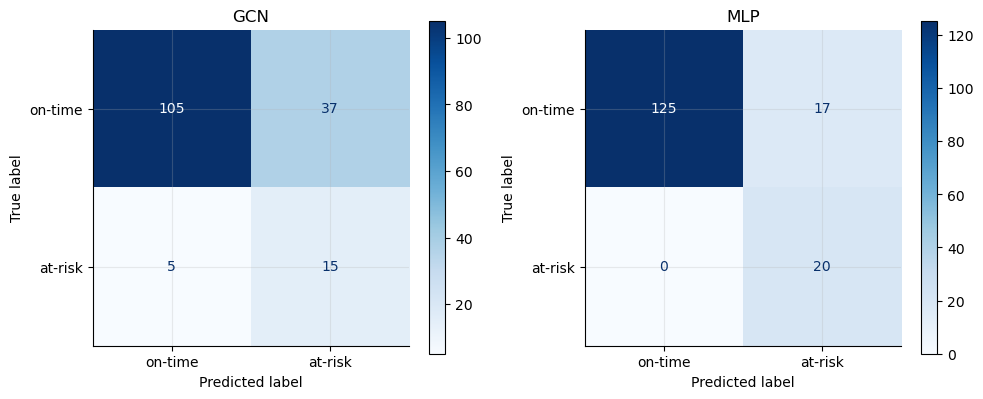

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_confusion_matrix(gcn_results["y_true"], gcn_results["y_pred"], ax=axes[0]); axes[0].set_title("GCN")
plot_confusion_matrix(mlp_results["y_true"], mlp_results["y_pred"], ax=axes[1]); axes[1].set_title("MLP")
plt.tight_layout(); plt.show()

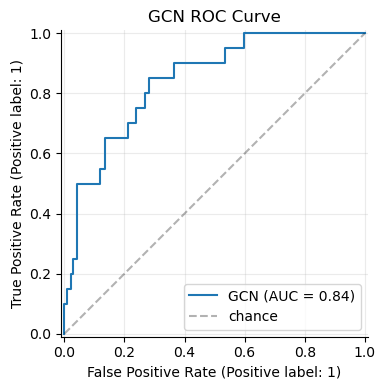

In [15]:
fig = plot_roc_curve(gcn_results["y_true"], gcn_results["y_prob"])
plt.title("GCN ROC Curve")
plt.show()

### Model Comparison Bar Chart

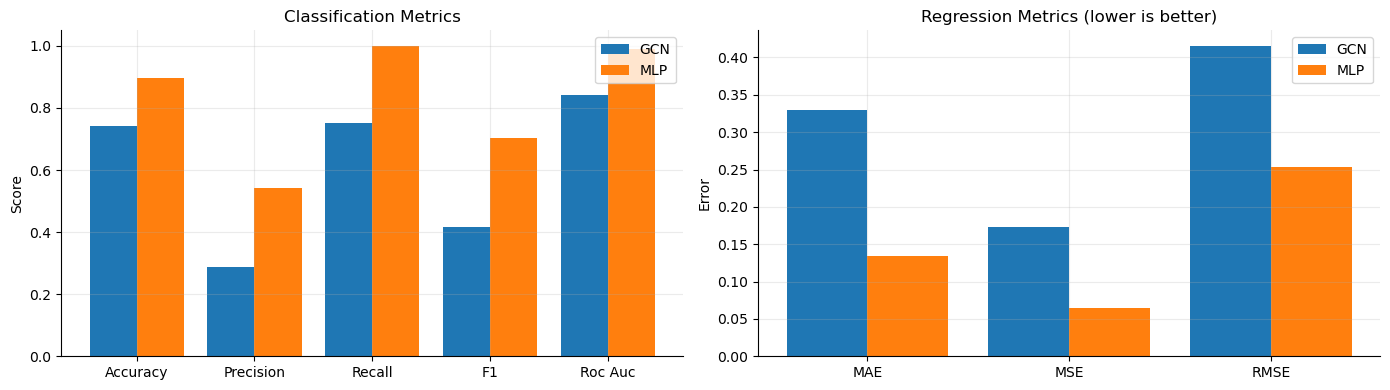

In [16]:
fig = plot_model_comparison({"GCN": gcn_results, "MLP": mlp_results})
plt.show()

### Predicted Stop Map

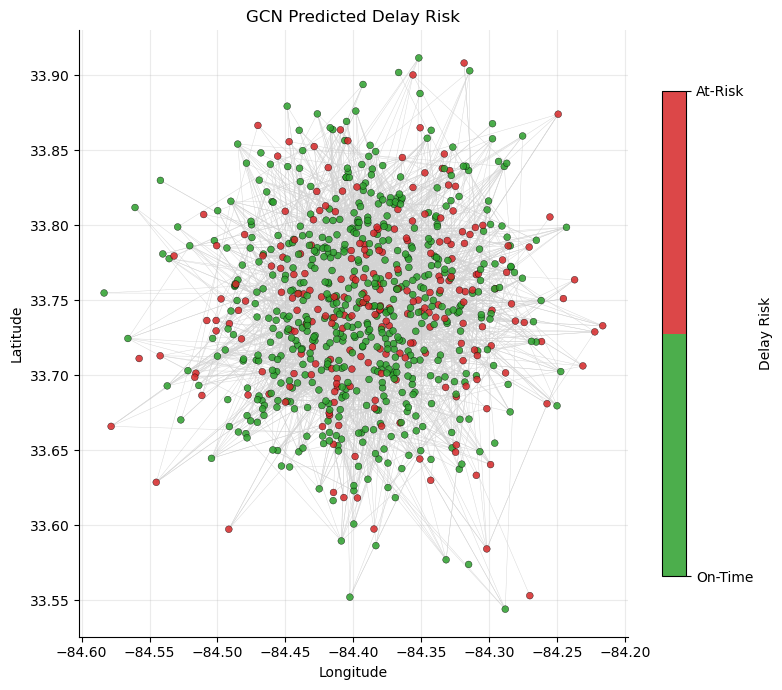

In [17]:
gcn_model.eval()
with torch.no_grad():
    all_preds = model_forward(gcn_model, data).argmax(dim=1).cpu().numpy()

fig = plot_graph_layout(data, predictions=all_preds)
plt.title("GCN Predicted Delay Risk")
plt.show()

## 8. Optuna Hyperparameter Search

Automatically tune GCN hyperparameters by optimising **validation F1**.
Adjust `N_TRIALS` to control how long the search runs.

In [18]:
import optuna
N_TRIALS = 30  # increase for a more thorough search


def build_gcn_cfg(params):
    return {
        "data": dict(cfg["data"]),
        "features": dict(cfg["features"]),
        "training": dict(cfg["training"]),
        "logging": dict(cfg["logging"]),
        "model": {
            "type": "gcn",
            "hidden_dim": params["hidden_dim"],
            "num_layers": params["num_layers"],
            "dropout": params["dropout"],
            "learning_rate": params["learning_rate"],
            "weight_decay": params["weight_decay"],
            "epochs": cfg["model"]["epochs"],
            "patience": cfg["model"]["patience"],
            "batch_size": cfg["model"]["batch_size"],
        },
    }


def objective(trial):
    params = {
        "hidden_dim": trial.suggest_categorical("hidden_dim", [16, 32, 64, 128]),
        "num_layers": trial.suggest_int("num_layers", 1, 4),
        "dropout": trial.suggest_float("dropout", 0.1, 0.6, step=0.05),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True),
    }
    trial_cfg = build_gcn_cfg(params)
    set_global_seed(trial_cfg["training"]["seed"])
    model = build_model(trial_cfg, in_dim=data.x.shape[1])
    Trainer(trial_cfg).train(model, data)
    # Evaluate on VALIDATION set—never peek at test during search
    val_results = evaluate(model, data, mask=data.val_mask)
    trial.set_user_attr("val_accuracy", val_results["accuracy"])
    # Use macro F1: robust even with few minority-class samples
    return val_results["f1_macro"]


print("Optimising validation macro-F1 (not accuracy) with a fixed seed for comparable trials.")
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=cfg["training"]["seed"]),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest Val Macro-F1: {study.best_value:.4f}")
print("Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

[I 2026-04-24 10:08:38,899] A new study created in memory with name: no-name-ed32af9d-7482-451c-8fa8-e91910ddbbd9


Optimising validation macro-F1 (not accuracy) with a fixed seed for comparable trials.


  0%|          | 0/30 [00:00<?, ?it/s]

Epoch   1 | loss=0.7183 val_loss=1.8302 | acc=0.123 val_acc=0.126 | MAE=0.7982 MSE=0.7341 RMSE=0.8568
Epoch   2 | loss=0.7605 val_loss=1.3134 | acc=0.127 val_acc=0.126 | MAE=0.7563 MSE=0.6574 RMSE=0.8108
Epoch   3 | loss=0.7243 val_loss=1.0936 | acc=0.127 val_acc=0.132 | MAE=0.7252 MSE=0.6021 RMSE=0.7759
Epoch   4 | loss=0.7171 val_loss=0.9703 | acc=0.127 val_acc=0.132 | MAE=0.7015 MSE=0.5606 RMSE=0.7487
Epoch   5 | loss=0.7648 val_loss=0.8930 | acc=0.136 val_acc=0.132 | MAE=0.6832 MSE=0.5289 RMSE=0.7273
Epoch   6 | loss=0.7287 val_loss=0.8406 | acc=0.140 val_acc=0.132 | MAE=0.6684 MSE=0.5038 RMSE=0.7098
Epoch   7 | loss=0.7303 val_loss=0.8033 | acc=0.144 val_acc=0.126 | MAE=0.6565 MSE=0.4835 RMSE=0.6953
Epoch   8 | loss=0.7131 val_loss=0.7758 | acc=0.146 val_acc=0.126 | MAE=0.6465 MSE=0.4668 RMSE=0.6832
Epoch   9 | loss=0.7167 val_loss=0.7548 | acc=0.148 val_acc=0.132 | MAE=0.6381 MSE=0.4527 RMSE=0.6728
Epoch  10 | loss=0.7336 val_loss=0.7389 | acc=0.150 val_acc=0.132 | MAE=0.6311 MSE

[I 2026-04-24 10:08:43,023] Trial 0 finished with value: 0.42815322850451654 and parameters: {'hidden_dim': 16, 'num_layers': 2, 'dropout': 0.2, 'learning_rate': 0.0002489577954043506, 'weight_decay': 0.0019124590142517383}. Best is trial 0 with value: 0.42815322850451654.


...

[I 2026-04-24 10:12:54,828] Trial 27 finished with value: 0.7080854813835646 and parameters: {'hidden_dim': 32, 'num_layers': 2, 'dropout': 0.35, 'learning_rate': 0.0016371917980421637, 'weight_decay': 0.00032946487110605845}. Best is trial 21 with value: 0.7466808284652151.


Epoch   5 | loss=0.7081 val_loss=1.2378 | acc=0.154 val_acc=0.164 | MAE=0.7581 MSE=0.6636 RMSE=0.8146
Epoch   6 | loss=0.7376 val_loss=1.1230 | acc=0.157 val_acc=0.182 | MAE=0.7336 MSE=0.6264 RMSE=0.7915
Epoch   7 | loss=0.6813 val_loss=0.9751 | acc=0.167 val_acc=0.195 | MAE=0.6978 MSE=0.5692 RMSE=0.7545
Epoch   8 | loss=0.6428 val_loss=0.8436 | acc=0.175 val_acc=0.233 | MAE=0.6553 MSE=0.5026 RMSE=0.7090
Epoch   9 | loss=0.6555 val_loss=0.7494 | acc=0.207 val_acc=0.258 | MAE=0.6149 MSE=0.4417 RMSE=0.6646
Epoch  10 | loss=0.6784 val_loss=0.6830 | acc=0.255 val_acc=0.289 | MAE=0.5778 MSE=0.3889 RMSE=0.6237
Epoch  11 | loss=0.6669 val_loss=0.6425 | acc=0.294 val_acc=0.327 | MAE=0.5491 MSE=0.3496 RMSE=0.5913
Epoch  12 | loss=0.6502 val_loss=0.6300 | acc=0.324 val_acc=0.346 | MAE=0.5374 MSE=0.3342 RMSE=0.5781
Epoch  13 | loss=0.6728 val_loss=0.6413 | acc=0.309 val_acc=0.340 | MAE=0.5461 MSE=0.3470 RMSE=0.5891
Epoch  14 | loss=0.6245 val_loss=0.6496 | acc=0.311 val_acc=0.333 | MAE=0.5525 MSE

[I 2026-04-24 10:13:01,691] Trial 28 finished with value: 0.6900584795321637 and parameters: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.5, 'learning_rate': 0.006882374405861627, 'weight_decay': 2.0364986828673e-05}. Best is trial 21 with value: 0.7466808284652151.


Epoch   7 | loss=0.8065 val_loss=0.7833 | acc=0.123 val_acc=0.145 | MAE=0.6595 MSE=0.4767 RMSE=0.6904
Epoch   8 | loss=0.8529 val_loss=0.7388 | acc=0.121 val_acc=0.145 | MAE=0.6360 MSE=0.4380 RMSE=0.6618
Epoch   9 | loss=0.7857 val_loss=0.7114 | acc=0.125 val_acc=0.145 | MAE=0.6177 MSE=0.4088 RMSE=0.6394
Epoch  10 | loss=0.7631 val_loss=0.7005 | acc=0.127 val_acc=0.145 | MAE=0.6078 MSE=0.3930 RMSE=0.6269
Epoch  11 | loss=0.7223 val_loss=0.6962 | acc=0.127 val_acc=0.145 | MAE=0.6021 MSE=0.3841 RMSE=0.6197
Epoch  12 | loss=0.6822 val_loss=0.6867 | acc=0.138 val_acc=0.157 | MAE=0.5892 MSE=0.3639 RMSE=0.6032
Epoch  13 | loss=0.7934 val_loss=0.6851 | acc=0.140 val_acc=0.157 | MAE=0.5810 MSE=0.3508 RMSE=0.5923
Epoch  14 | loss=0.7985 val_loss=0.6903 | acc=0.142 val_acc=0.157 | MAE=0.5771 MSE=0.3443 RMSE=0.5868
Epoch  15 | loss=0.7633 val_loss=0.6852 | acc=0.144 val_acc=0.164 | MAE=0.5751 MSE=0.3427 RMSE=0.5854
Epoch  16 | loss=0.7384 val_loss=0.6821 | acc=0.146 val_acc=0.164 | MAE=0.5799 MSE

[I 2026-04-24 10:13:05,844] Trial 29 finished with value: 0.6558441558441558 and parameters: {'hidden_dim': 16, 'num_layers': 2, 'dropout': 0.6, 'learning_rate': 0.004544842544219579, 'weight_decay': 5.6986899504538847e-05}. Best is trial 21 with value: 0.7466808284652151.

Best Val Macro-F1: 0.7467
Best hyperparameters:
  hidden_dim: 128
  num_layers: 2
  dropout: 0.45000000000000007
  learning_rate: 0.006510860497558633
  weight_decay: 7.864988408044846e-05


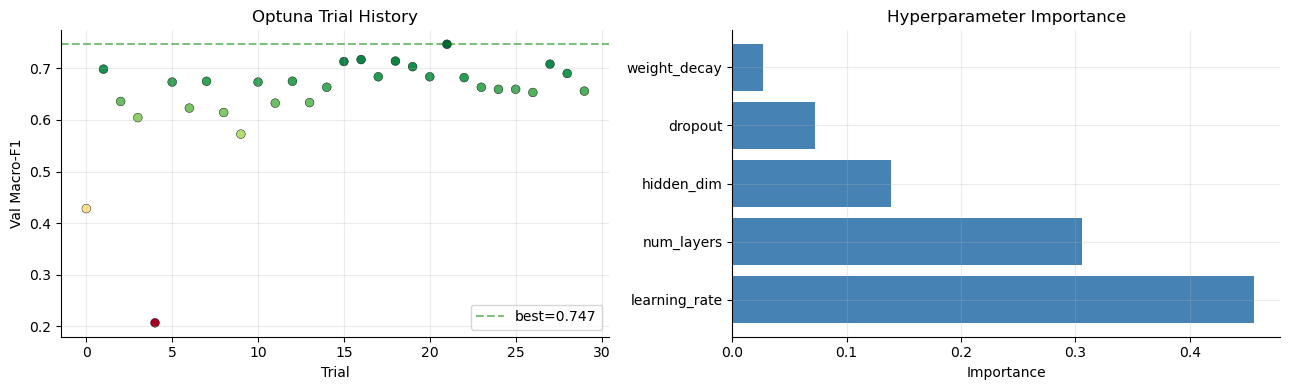

In [19]:
# Visualise search results
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Trial history
trials_df = study.trials_dataframe()
axes[0].scatter(trials_df["number"], trials_df["value"], c=trials_df["value"],
                cmap="RdYlGn", edgecolors="k", linewidths=0.3, s=40)
axes[0].axhline(study.best_value, color="green", linestyle="--", alpha=0.5, label=f"best={study.best_value:.3f}")
axes[0].set_xlabel("Trial"); axes[0].set_ylabel("Val Macro-F1"); axes[0].set_title("Optuna Trial History")
axes[0].legend()

# Parameter importances (fANOVA needs variance across trials)
try:
    importances = optuna.importance.get_param_importances(study)
    axes[1].barh(list(importances.keys()), list(importances.values()), color="steelblue")
    axes[1].set_xlabel("Importance"); axes[1].set_title("Hyperparameter Importance")
except RuntimeError:
    axes[1].text(0.5, 0.5, "Importance unavailable\n(too little variance across trials)",
                 ha="center", va="center", transform=axes[1].transAxes, fontsize=11)
    axes[1].set_title("Hyperparameter Importance")

plt.tight_layout(); plt.show()

In [20]:
# Retrain with the best hyperparameters and keep the run with the best validation macro-F1
FINAL_RETRAIN_SEEDS = [SEED, SEED + 1, SEED + 2]

best_cfg = build_gcn_cfg(study.best_params)
best_model = None
best_history = None
best_results = None
best_val_results = None
selected_seed = None
selected_val_f1 = float("-inf")

for run_seed in FINAL_RETRAIN_SEEDS:
    run_cfg = clone_cfg(best_cfg)
    run_cfg["training"]["seed"] = run_seed
    set_global_seed(run_seed)

    model = build_model(run_cfg, in_dim=data.x.shape[1])
    history = Trainer(run_cfg).train(model, data)
    val_results = evaluate(model, data, mask=data.val_mask)

    if val_results["f1_macro"] > selected_val_f1:
        selected_val_f1 = val_results["f1_macro"]
        selected_seed = run_seed
        best_model = model
        best_history = history
        best_val_results = val_results
        best_results = evaluate(model, data)

print(f"Selected retrain seed: {selected_seed}")
print(f"Validation macro-F1: {best_val_results['f1_macro']:.4f}")
print(f"Validation accuracy: {best_val_results['accuracy']:.4f}")
print("\nOptimised GCN:")
print(best_results["classification_report"])
print(f"  MAE:  {best_results['mae']:.4f}")
print(f"  MSE:  {best_results['mse']:.4f}")
print(f"  RMSE: {best_results['rmse']:.4f}")
print(f"\nF1: {best_results['f1']:.4f}  |  F1-Macro: {best_results['f1_macro']:.4f}  |  ROC-AUC: {best_results['roc_auc']:.4f}")

Epoch   1 | loss=0.8517 val_loss=0.7752 | acc=0.123 val_acc=0.119 | MAE=0.6429 MSE=0.4382 RMSE=0.6619
Epoch   2 | loss=0.8198 val_loss=1.0414 | acc=0.146 val_acc=0.164 | MAE=0.7398 MSE=0.6140 RMSE=0.7836
Epoch   3 | loss=0.7101 val_loss=1.3766 | acc=0.146 val_acc=0.164 | MAE=0.7789 MSE=0.6992 RMSE=0.8362
Epoch   4 | loss=0.6715 val_loss=1.2748 | acc=0.152 val_acc=0.170 | MAE=0.7578 MSE=0.6712 RMSE=0.8193
Epoch   5 | loss=0.6643 val_loss=1.0327 | acc=0.163 val_acc=0.189 | MAE=0.7115 MSE=0.5964 RMSE=0.7723
Epoch   6 | loss=0.6094 val_loss=0.8471 | acc=0.173 val_acc=0.226 | MAE=0.6569 MSE=0.5107 RMSE=0.7147
Epoch   7 | loss=0.6392 val_loss=0.8413 | acc=0.188 val_acc=0.239 | MAE=0.6489 MSE=0.5046 RMSE=0.7104
Epoch   8 | loss=0.5911 val_loss=0.7894 | acc=0.219 val_acc=0.258 | MAE=0.6246 MSE=0.4709 RMSE=0.6862
Epoch   9 | loss=0.6349 val_loss=0.7146 | acc=0.271 val_acc=0.308 | MAE=0.5824 MSE=0.4148 RMSE=0.6441
Epoch  10 | loss=0.5763 val_loss=0.6182 | acc=0.384 val_acc=0.415 | MAE=0.5222 MSE

Selected retrain seed: 10
Validation macro-F1: 0.7467
Validation accuracy: 0.8679

Optimised GCN:
              precision    recall  f1-score   support

     on-time       0.95      0.82      0.88       142
     at-risk       0.36      0.70      0.47        20

    accuracy                           0.81       162
   macro avg       0.66      0.76      0.68       162
weighted avg       0.88      0.81      0.83       162

  MAE:  0.2335
  MSE:  0.1190
  RMSE: 0.3450

F1: 0.4746  |  F1-Macro: 0.6788  |  ROC-AUC: 0.8930


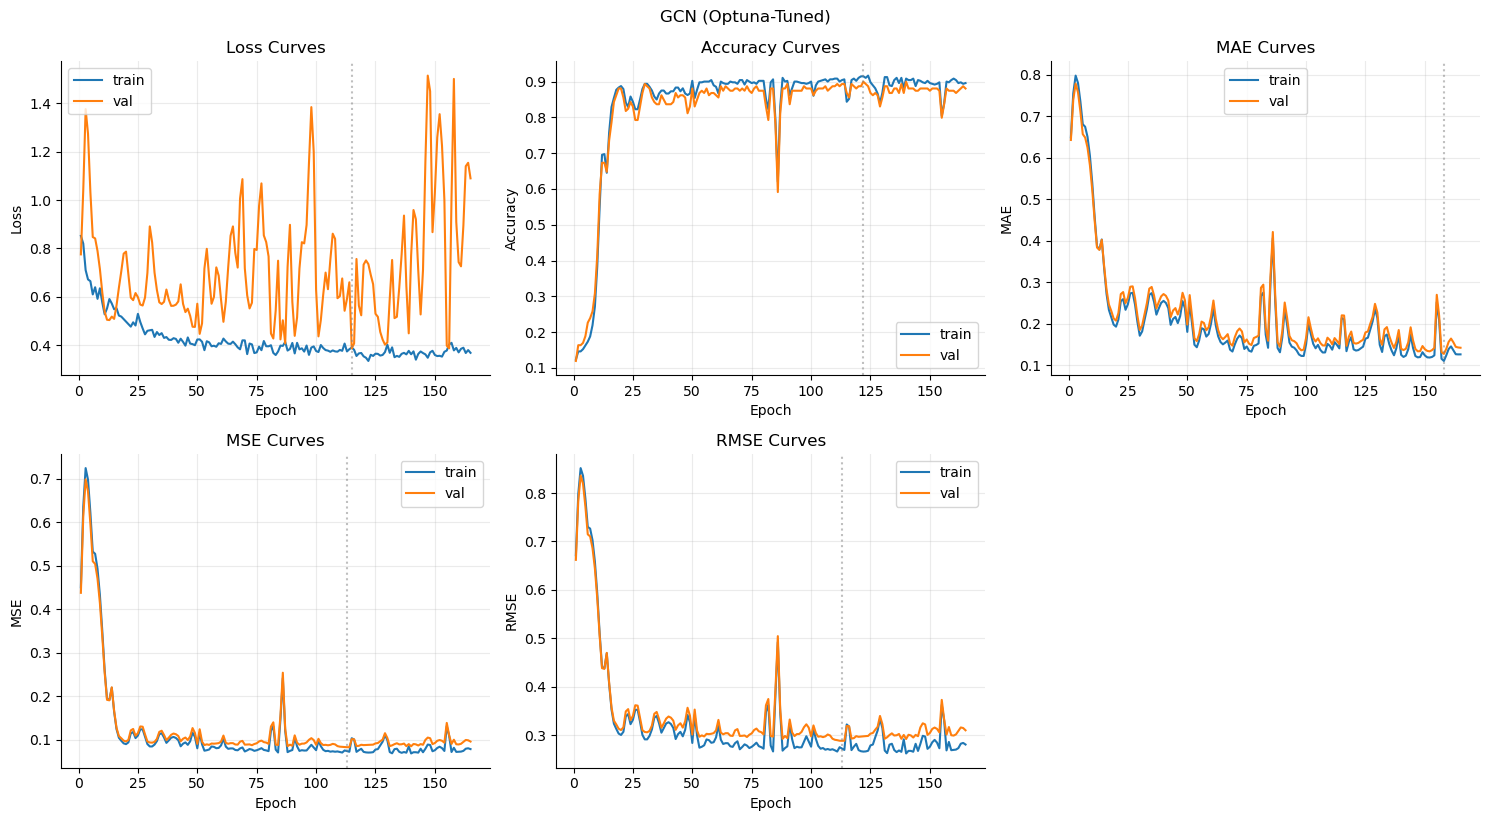

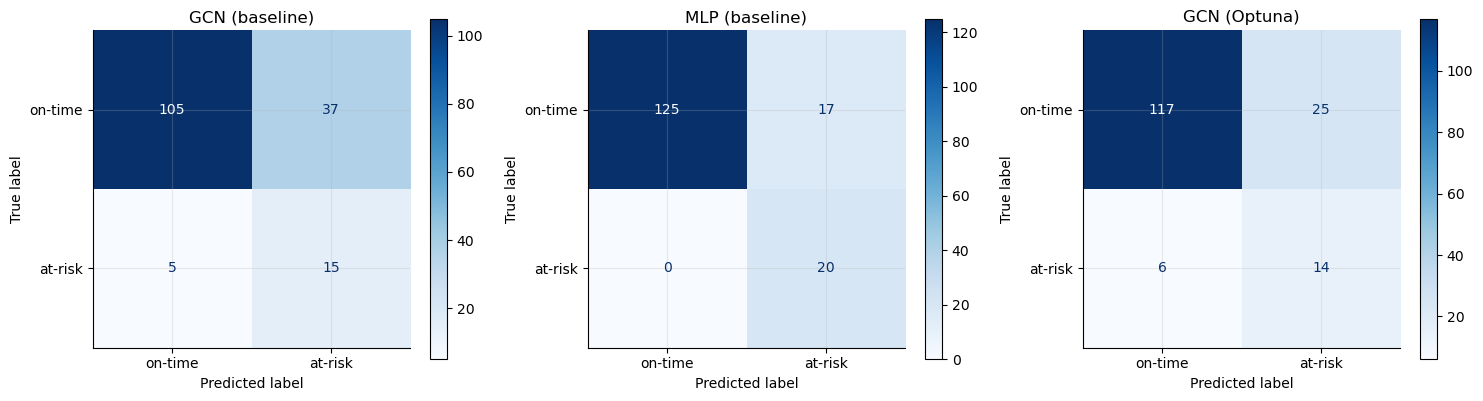

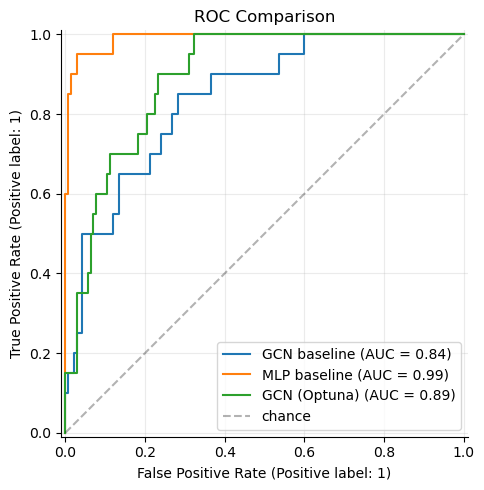

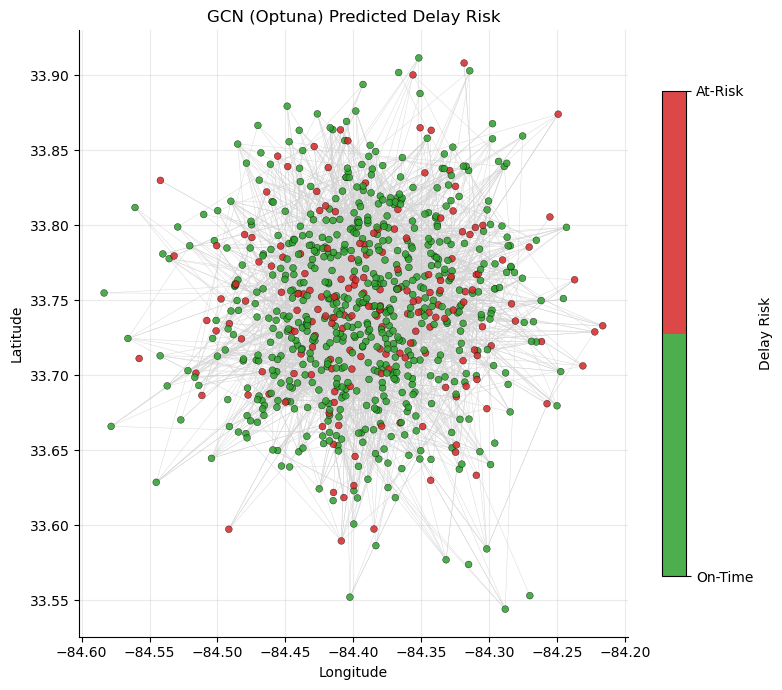

In [21]:
# ── Optuna model: training curves ──
fig = plot_training_curves(best_history)
plt.suptitle("GCN (Optuna-Tuned)", y=1.02)
plt.show()

# ── Side-by-side confusion matrices: all three models ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_confusion_matrix(gcn_results["y_true"], gcn_results["y_pred"], ax=axes[0]); axes[0].set_title("GCN (baseline)")
plot_confusion_matrix(mlp_results["y_true"], mlp_results["y_pred"], ax=axes[1]); axes[1].set_title("MLP (baseline)")
plot_confusion_matrix(best_results["y_true"], best_results["y_pred"], ax=axes[2]); axes[2].set_title("GCN (Optuna)")
plt.tight_layout(); plt.show()

# ── ROC curves overlay ──
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(gcn_results["y_true"], gcn_results["y_prob"], ax=ax, name="GCN baseline")
RocCurveDisplay.from_predictions(mlp_results["y_true"], mlp_results["y_prob"], ax=ax, name="MLP baseline")
RocCurveDisplay.from_predictions(best_results["y_true"], best_results["y_prob"], ax=ax, name="GCN (Optuna)")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="chance")
ax.set_title("ROC Comparison"); ax.legend()
plt.tight_layout(); plt.show()

# ── Predicted stop map with Optuna model ──
best_model.eval()
with torch.no_grad():
    optuna_preds = model_forward(best_model, data).argmax(dim=1).cpu().numpy()
fig = plot_graph_layout(data, predictions=optuna_preds)
plt.title("GCN (Optuna) Predicted Delay Risk")
plt.show()

In [22]:
models = ["GCN", "MLP", "GCN (Optuna)"]
results_list = [gcn_results, mlp_results, best_results]

summary = pd.DataFrame({
    "Model":      models,
    "Accuracy":   [r["accuracy"]  for r in results_list],
    "Precision":  [r["precision"] for r in results_list],
    "Recall":     [r["recall"]    for r in results_list],
    "F1":         [r["f1"]        for r in results_list],
    "F1-Macro":   [r["f1_macro"]  for r in results_list],
    "ROC-AUC":    [r["roc_auc"]   for r in results_list],
    "MAE":        [r["mae"]       for r in results_list],
    "MSE":        [r["mse"]       for r in results_list],
    "RMSE":       [r["rmse"]      for r in results_list],
}).round(4)

higher_better = ["Accuracy", "Precision", "Recall", "F1", "F1-Macro", "ROC-AUC"]
lower_better  = ["MAE", "MSE", "RMSE"]

(summary.style
    .highlight_max(subset=higher_better, color="black")
    .highlight_min(subset=lower_better, color="black")
)

,Model,Accuracy,Precision,Recall,F1,F1-Macro,ROC-AUC,MAE,MSE,RMSE
0,GCN,0.740700,0.288500,0.750000,0.416700,0.625000,0.842300,0.330000,0.172700,0.415500
1,MLP,0.895100,0.540500,1.000000,0.701800,0.819000,0.990100,0.134300,0.064400,0.253800
2,GCN (Optuna),0.808600,0.359000,0.700000,0.474600,0.678800,0.893000,0.233500,0.119000,0.345000


For real data: `python -m marta_gnn.main --live`